#### ============================================================================
### **ANÁLISIS DEL TRÁFICO AÉREO EN EL AEROPUERTO JORGE CHÁVEZ (2019–2025)**
#### ============================================================================
##### *Día 1: Carga, exploración inicial y preparación de variables*


**1. IMPORTACIÓN DE LIBRERÍAS**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

** Configuración general de visualización







In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

**2. MONTAJE DE GOOGLE DRIVE Y CARGA DEL CSV**





In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


** Ruta del archivo dentro de Google Drive


In [4]:
ruta = "/content/drive/MyDrive/ProyectosColab/trafico_lap.csv"


** Carga del archivo CSV


In [5]:
try:
    df = pd.read_csv(ruta)
    print(f"Archivo cargado correctamente: {ruta}")
except FileNotFoundError:
    print("Error: no se encontró el archivo. Verifica la ruta y el nombre del CSV.")
    df = None


Archivo cargado correctamente: /content/drive/MyDrive/ProyectosColab/trafico_lap.csv


**3. EXPLORACIÓN INICIAL DEL DATASET**


In [6]:
if df is not None:
    print("\nTamaño del dataset:")
    print(df.shape)

    print("\nInformación general:")
    df.info()

    print("\nPrimeras filas del dataset:")
    display(df.head())

    print("\nColumnas disponibles:")
    print(df.columns.tolist())


Tamaño del dataset:
(84, 8)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ANIO                           84 non-null     int64  
 1   MES                            84 non-null     int64  
 2   ENTIDAD PRESTADORA             84 non-null     object 
 3   CONCESION                      84 non-null     object 
 4   TOTAL CARGA NACIONAL           84 non-null     float64
 5   TOTAL CARGA INTERNACIONA       84 non-null     float64
 6   TOTAL OPERACION NACIONAL       84 non-null     int64  
 7   TOTAL OPERACION INTERNACIONAL  84 non-null     int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 5.4+ KB

Primeras filas del dataset:


,ANIO,MES,ENTIDAD PRESTADORA,CONCESION,TOTAL CARGA NACIONAL,TOTAL CARGA INTERNACIONA,TOTAL OPERACION NACIONAL,TOTAL OPERACION INTERNACIONAL
0,2019,1,LIMA AIRPORT PARTNERS S.R.L. - LAP,AEROPUERTO INTERNACIONAL JORGE CHÁVEZ,1892.709,21963.968,8437,7289
1,2019,2,LIMA AIRPORT PARTNERS S.R.L. - LAP,AEROPUERTO INTERNACIONAL JORGE CHÁVEZ,1887.864,15837.726,8096,6527
2,2019,3,LIMA AIRPORT PARTNERS S.R.L. - LAP,AEROPUERTO INTERNACIONAL JORGE CHÁVEZ,2257.338,18690.349,9056,7105
3,2019,4,LIMA AIRPORT PARTNERS S.R.L. - LAP,AEROPUERTO INTERNACIONAL JORGE CHÁVEZ,2108.846,17872.451,9338,6720
4,2019,5,LIMA AIRPORT PARTNERS S.R.L. - LAP,AEROPUERTO INTERNACIONAL JORGE CHÁVEZ,2153.860,18309.415,10353,6936



Columnas disponibles:
['ANIO', 'MES', 'ENTIDAD PRESTADORA', 'CONCESION', 'TOTAL CARGA NACIONAL', 'TOTAL CARGA INTERNACIONA', 'TOTAL OPERACION NACIONAL', 'TOTAL OPERACION INTERNACIONAL']


**4. LIMPIEZA BÁSICA DE DATOS**


In [7]:
if df is not None:
    # 4.1 Valores nulos
    print("\nValores nulos por columna:")
    nulos = df.isnull().sum()
    display(nulos[nulos > 0])

    if nulos.sum() == 0:
        print("No se encontraron valores nulos en el dataset.")

    # 4.2 Duplicados
    duplicados = df.duplicated().sum()
    print(f"\nFilas duplicadas encontradas: {duplicados}")

    if duplicados > 0:
        df = df.drop_duplicates().copy()
        print("Filas duplicadas eliminadas correctamente.")
    else:
        print("No se encontraron filas duplicadas.")


Valores nulos por columna:


,0


No se encontraron valores nulos en el dataset.

Filas duplicadas encontradas: 0
No se encontraron filas duplicadas.


**5. VALIDACIÓN Y PREPARACIÓN DE COLUMNAS**



In [8]:
# En este dataset las columnas esperadas son:
# ANIO, MES, ENTIDAD PRESTADORA, CONCESION,
# TOTAL CARGA NACIONAL, TOTAL CARGA INTERNACIONA,
# TOTAL OPERACION NACIONAL, TOTAL OPERACION INTERNACIONAL

if df is not None:
    print("\nTipos de datos actuales:")
    print(df.dtypes)

    # Crear una columna de fecha para análisis temporal
    # Se construye con ANIO y MES, usando el primer día del mes.
    df["FECHA"] = pd.to_datetime(
        df["ANIO"].astype(str) + "-" + df["MES"].astype(str) + "-01",
        errors="coerce"
    )

    # Crear variables derivadas para análisis
    df["AÑO"] = df["FECHA"].dt.year
    df["MES_NUM"] = df["FECHA"].dt.month
    df["MES_NOMBRE"] = df["FECHA"].dt.strftime("%B")

    # Columnas de análisis principales
    df["TOTAL_CARGA"] = (
        df["TOTAL CARGA NACIONAL"] +
        df["TOTAL CARGA INTERNACIONA"]
    )

    df["TOTAL_OPERACIONES"] = (
        df["TOTAL OPERACION NACIONAL"] +
        df["TOTAL OPERACION INTERNACIONAL"]
    )

    print("\nColumnas derivadas creadas correctamente.")
    display(df[["ANIO", "MES", "FECHA", "AÑO", "MES_NUM", "MES_NOMBRE", "TOTAL_CARGA", "TOTAL_OPERACIONES"]].head())


Tipos de datos actuales:
ANIO                               int64
MES                                int64
ENTIDAD PRESTADORA                object
CONCESION                         object
TOTAL CARGA NACIONAL             float64
TOTAL CARGA INTERNACIONA         float64
TOTAL OPERACION NACIONAL           int64
TOTAL OPERACION INTERNACIONAL      int64
dtype: object

Columnas derivadas creadas correctamente.


,ANIO,MES,FECHA,AÑO,MES_NUM,MES_NOMBRE,TOTAL_CARGA,TOTAL_OPERACIONES
0,2019,1,2019-01-01,2019,1,January,23856.677,15726
1,2019,2,2019-02-01,2019,2,February,17725.590,14623
2,2019,3,2019-03-01,2019,3,March,20947.687,16161
3,2019,4,2019-04-01,2019,4,April,19981.297,16058
4,2019,5,2019-05-01,2019,5,May,20463.275,17289


**6. DESCRIPCIÓN BÁSICA DE LAS VARIABLES CLAVE**


In [9]:
if df is not None:
    print("\nResumen estadístico de las variables numéricas:")
    display(df[[
        "TOTAL CARGA NACIONAL",
        "TOTAL CARGA INTERNACIONA",
        "TOTAL OPERACION NACIONAL",
        "TOTAL OPERACION INTERNACIONAL",
        "TOTAL_CARGA",
        "TOTAL_OPERACIONES"
    ]].describe())


Resumen estadístico de las variables numéricas:


,TOTAL CARGA NACIONAL,TOTAL CARGA INTERNACIONA,TOTAL OPERACION NACIONAL,TOTAL OPERACION INTERNACIONAL,TOTAL_CARGA,TOTAL_OPERACIONES
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,2141.481696,16994.778048,8205.619048,4797.357143,19136.259744,13002.976190
std,456.493960,3034.677017,2872.166287,2002.705975,3350.502701,4710.572474
min,518.897440,8083.799710,970.000000,516.000000,8602.697150,1486.000000
25%,1856.462178,15013.038320,7239.500000,3405.250000,17046.336340,10614.250000
50%,2242.222560,16798.305255,9062.000000,5439.000000,18869.877635,14579.500000
75%,2420.352250,18466.620592,9831.750000,6537.750000,20948.217092,16317.000000
max,3141.589000,23221.259000,20725.000000,7289.000000,25720.677000,27339.000000


##### *Día 2: Análisis Temporal y Comparación Nacional vs Internacional*


**7. PRIMERA VISUALIZACIÓN SIMPLE**

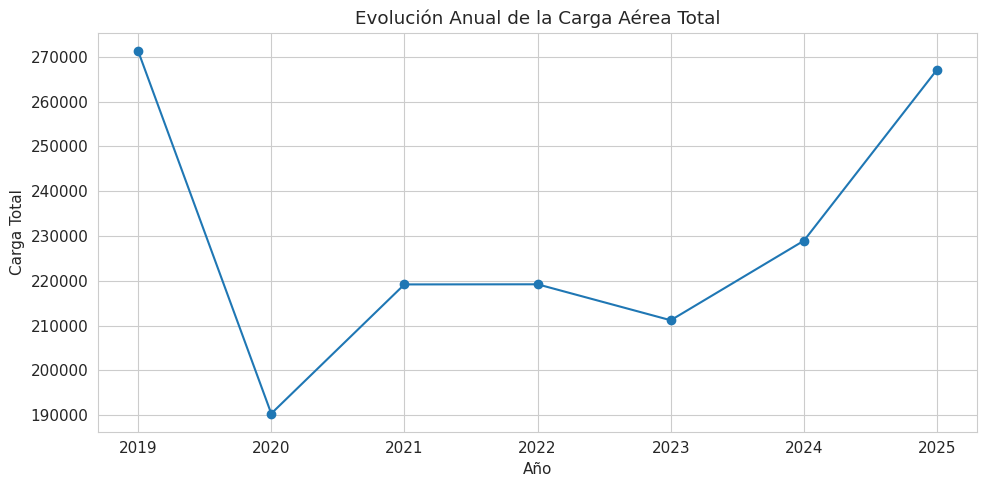

In [10]:
# Se agrupa la carga aérea total por año con el objetivo de
# analizar su comportamiento a lo largo del periodo 2019–2025.

carga_anual = df.groupby("AÑO")["TOTAL_CARGA"].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    carga_anual.index,
    carga_anual.values,
    marker="o"
)

plt.title("Evolución Anual de la Carga Aérea Total")
plt.xlabel("Año")
plt.ylabel("Carga Total")
plt.xticks(carga_anual.index)
plt.grid(True)

plt.tight_layout()
plt.show()

**8. Evolución Anual de las Operaciones Aéreas**

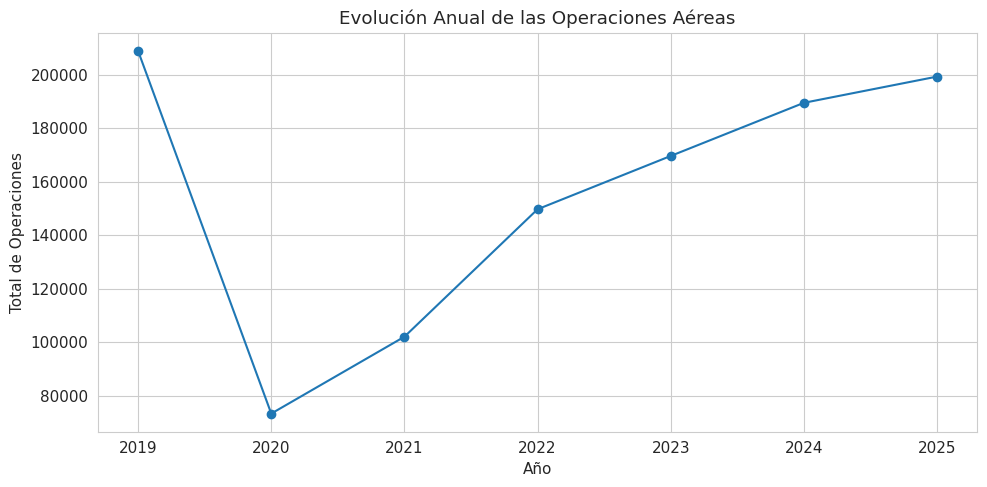

In [11]:
# Las operaciones representan los movimientos realizados
# por las aeronaves. Su análisis permite evaluar la actividad
# aeroportuaria durante los años estudiados.

operaciones_anual = (
    df.groupby("AÑO")["TOTAL_OPERACIONES"]
      .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    operaciones_anual.index,
    operaciones_anual.values,
    marker="o"
)

plt.title("Evolución Anual de las Operaciones Aéreas")
plt.xlabel("Año")
plt.ylabel("Total de Operaciones")
plt.xticks(operaciones_anual.index)
plt.grid(True)

plt.tight_layout()
plt.show()

**9. Comparación de Carga Nacional e Internacional**

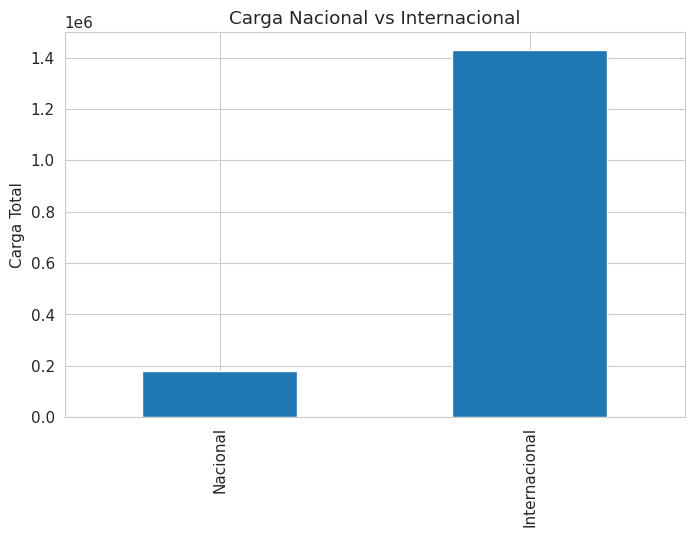

In [12]:
# Se compara el volumen acumulado de carga nacional e
# internacional para identificar cuál tiene mayor participación
# dentro de las operaciones del aeropuerto.

carga_comparacion = pd.Series({
    "Nacional": df["TOTAL CARGA NACIONAL"].sum(),
    "Internacional": df["TOTAL CARGA INTERNACIONA"].sum()
})

plt.figure(figsize=(8,5))

carga_comparacion.plot(kind="bar")

plt.title("Carga Nacional vs Internacional")
plt.ylabel("Carga Total")

plt.show()

**10. Participación de la Carga Aérea**

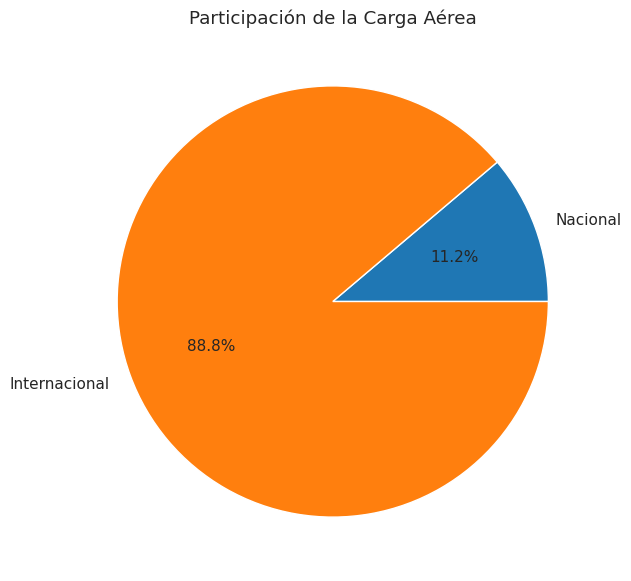

In [13]:
# El gráfico circular permite visualizar la proporción
# relativa de la carga nacional e internacional.

plt.figure(figsize=(7,7))

carga_comparacion.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Participación de la Carga Aérea")
plt.ylabel("")

plt.show()

**11. Comparación de Operaciones Nacionales e Internacionales**

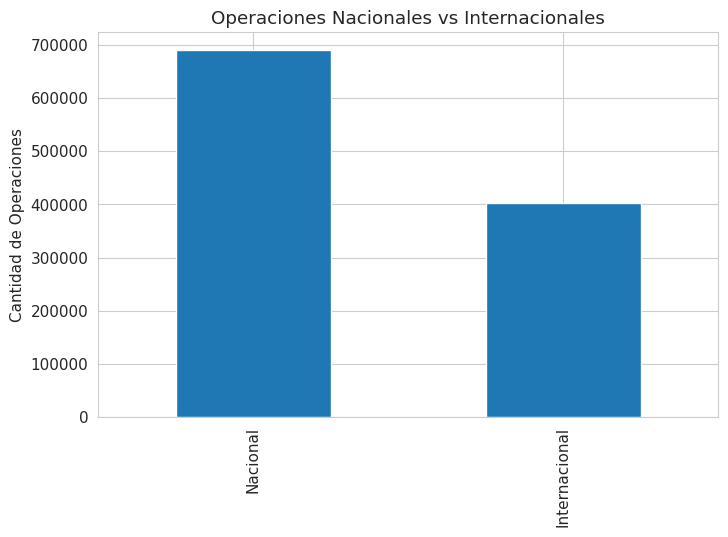

In [14]:
# Se analiza la distribución de las operaciones aéreas
# según su ámbito nacional o internacional.

operaciones_comparacion = pd.Series({
    "Nacional": df["TOTAL OPERACION NACIONAL"].sum(),
    "Internacional": df["TOTAL OPERACION INTERNACIONAL"].sum()
})

plt.figure(figsize=(8,5))

operaciones_comparacion.plot(
    kind="bar"
)

plt.title("Operaciones Nacionales vs Internacionales")
plt.ylabel("Cantidad de Operaciones")

plt.show()

**12. Participación de Operaciones**

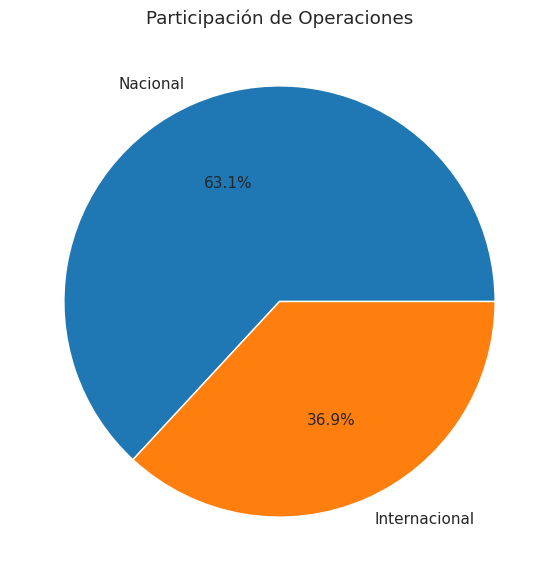

In [15]:
# Se representa gráficamente la participación porcentual
# de las operaciones nacionales e internacionales.

plt.figure(figsize=(7,7))

operaciones_comparacion.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Participación de Operaciones")
plt.ylabel("")

plt.show()

##### *Día 3: Análisis Mensual y Estacionalidad*

**13. Evolución Mensual de la Carga Aérea**

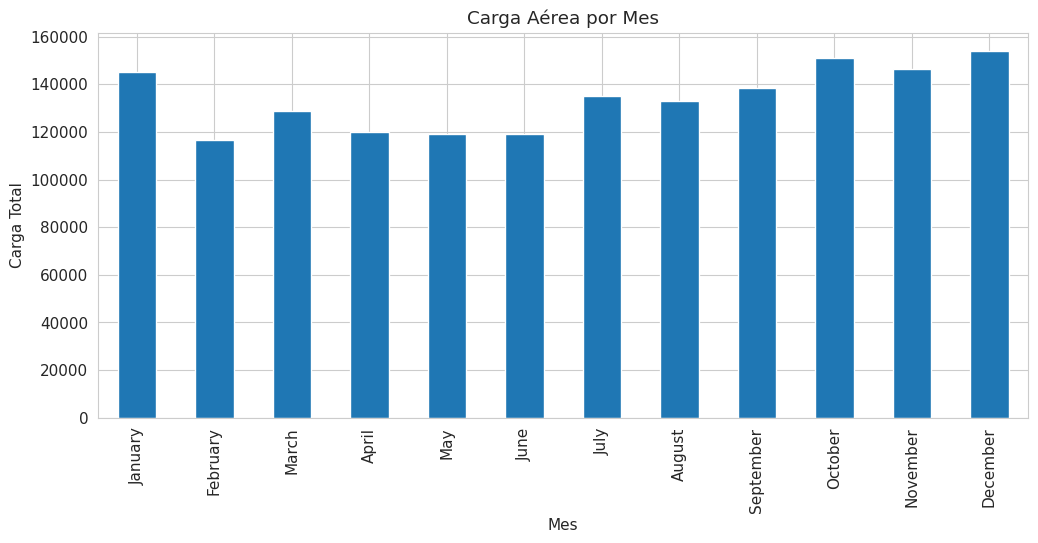

In [16]:
# Se analiza la distribución mensual de la carga aérea
# para identificar periodos de mayor y menor actividad.
carga_mensual = (
    df.groupby("MES_NOMBRE")["TOTAL_CARGA"]
      .sum()
)

orden_meses = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

carga_mensual = carga_mensual.reindex(orden_meses)

plt.figure(figsize=(12,5))

carga_mensual.plot(kind="bar")

plt.title("Carga Aérea por Mes")
plt.xlabel("Mes")
plt.ylabel("Carga Total")

plt.show()

**14. Evolución Mensual de las Operaciones**

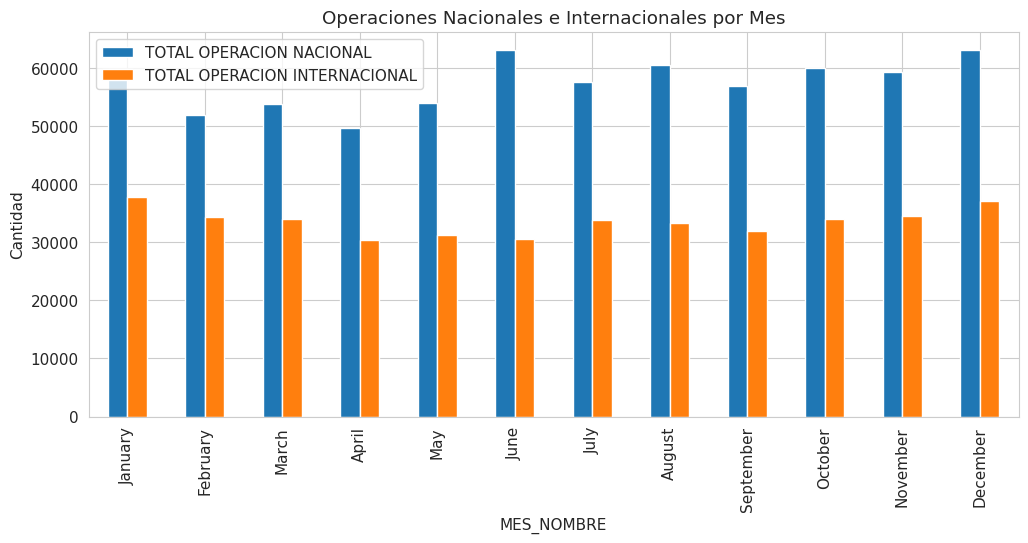

In [17]:
# Se analiza la distribución mensual de las operaciones
# nacionales e internacionales con el objetivo de identificar
# diferencias en su comportamiento y posibles patrones
# estacionales a lo largo del periodo estudiado.
operaciones_tipo = df.groupby("MES_NOMBRE")[
    [
        "TOTAL OPERACION NACIONAL",
        "TOTAL OPERACION INTERNACIONAL"
    ]
].sum()

operaciones_tipo = operaciones_tipo.reindex(orden_meses)

operaciones_tipo.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Operaciones Nacionales e Internacionales por Mes"
)

plt.ylabel("Cantidad")
plt.show()

**15. Top 5 Meses con Mayor Carga**

In [ ]:
top_carga = (
    df.groupby("MES_NOMBRE")["TOTAL_CARGA"]
      .sum()
      .sort_values(ascending=False)
)

top_carga.head(5)

,TOTAL_CARGA
MES_NOMBRE,
December,153971.32992
October,151089.33506
November,146605.81418
January,145047.99197
September,138661.51027


**16. Top 5 Meses con Más Operaciones**

In [19]:
top_operaciones = (
    df.groupby("MES_NOMBRE")["TOTAL_OPERACIONES"]
      .sum()
      .sort_values(ascending=False)
)

top_operaciones.head(5)

,TOTAL_OPERACIONES
MES_NOMBRE,
December,100105
January,97536
October,94098
November,93864
August,93755


**17. Heatmap de Actividad por Año y Mes**

Esta sección suele impresionar bastante en portafolios.

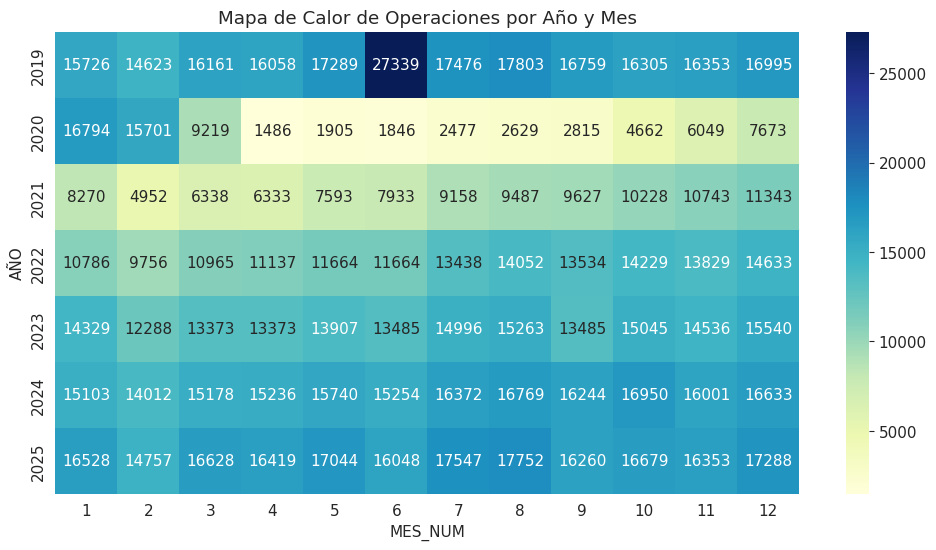

In [20]:
tabla_heatmap = pd.pivot_table(
    df,
    values="TOTAL_OPERACIONES",
    index="AÑO",
    columns="MES_NUM",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Mapa de Calor de Operaciones por Año y Mes")

plt.show()

##### *Día 4: Indicadores Clave e Insights del Tráfico Aéreo*

**18. Carga Total Transportada**

In [21]:
# Se calcula la carga total movilizada durante
# todo el periodo analizado (2019-2025).

carga_total = df["TOTAL_CARGA"].sum()

print(f"Carga total transportada: {carga_total:,.0f}")

Carga total transportada: 1,607,446


**19. Total de Operaciones Aéreas**

In [ ]:
# Se calcula el total de operaciones realizadas
# durante todo el periodo de estudio.

operaciones_total = df["TOTAL_OPERACIONES"].sum()

print(f"Total de operaciones aéreas: {operaciones_total:,.0f}")

Total de operaciones aéreas: 1,092,250


**20. Año con Mayor Carga Transportada**

In [23]:
# Se identifica el año que registró el mayor
# volumen de carga aérea transportada.

carga_anual = (
    df.groupby("AÑO")["TOTAL_CARGA"]
      .sum()
)

anio_max_carga = carga_anual.idxmax()
valor_max_carga = carga_anual.max()

print(
    f"Año con mayor carga transportada: "
    f"{anio_max_carga} ({valor_max_carga:,.0f})"
)

Año con mayor carga transportada: 2019 (271,326)


**21. Año con Mayor Número de Operaciones**

In [24]:
# Se identifica el año con la mayor cantidad
# de operaciones aéreas registradas.

operaciones_anual = (
    df.groupby("AÑO")["TOTAL_OPERACIONES"]
      .sum()
)

anio_max_operaciones = operaciones_anual.idxmax()
valor_max_operaciones = operaciones_anual.max()

print(
    f"Año con más operaciones: "
    f"{anio_max_operaciones} ({valor_max_operaciones:,.0f})"
)

Año con más operaciones: 2019 (208,887)


**22. Año con Menor Carga Transportada**

In [25]:
# Se identifica el año con el menor volumen
# de carga aérea transportada.

anio_min_carga = carga_anual.idxmin()
valor_min_carga = carga_anual.min()

print(
    f"Año con menor carga transportada: "
    f"{anio_min_carga} ({valor_min_carga:,.0f})"
)

Año con menor carga transportada: 2020 (190,365)


**23. Año con Menor Número de Operaciones**

In [26]:
# Se identifica el año con la menor cantidad
# de operaciones registradas.

anio_min_operaciones = operaciones_anual.idxmin()
valor_min_operaciones = operaciones_anual.min()

print(
    f"Año con menos operaciones: "
    f"{anio_min_operaciones} ({valor_min_operaciones:,.0f})"
)

Año con menos operaciones: 2020 (73,256)


**24. Variación Anual de la Carga (%)**

In [27]:
# Se calcula el crecimiento o disminución
# porcentual de la carga respecto al año anterior.

variacion_carga = (
    carga_anual.pct_change() * 100
)

display(
    variacion_carga.round(2)
)

,TOTAL_CARGA
AÑO,
2019,NaN
2020,-29.84
2021,15.15
2022,0.01
2023,-3.66
2024,8.41
2025,16.68


**25. Variación Anual de las Operaciones (%)**

In [28]:
# Se calcula la variación porcentual anual
# de las operaciones aéreas.

variacion_operaciones = (
    operaciones_anual.pct_change() * 100
)

display(
    variacion_operaciones.round(2)
)

,TOTAL_OPERACIONES
AÑO,
2019,NaN
2020,-64.93
2021,39.24
2022,46.74
2023,13.32
2024,11.72
2025,5.18


**26. Evolución de la Variación Anual de la Carga**

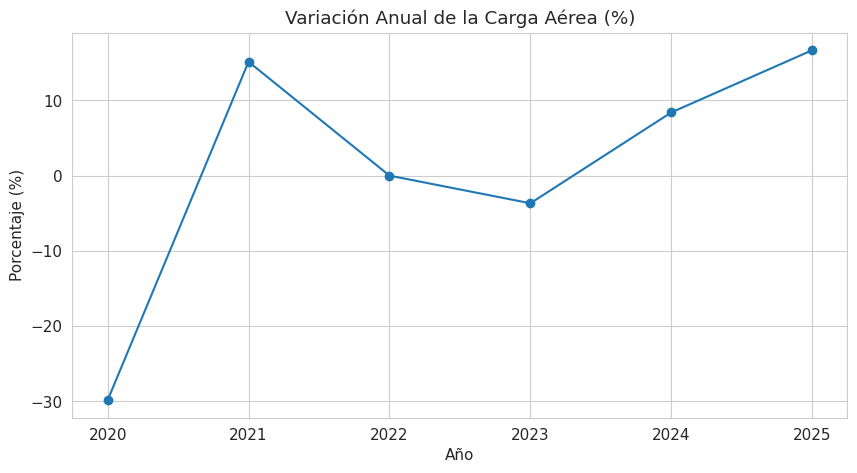

In [29]:
# Visualización de la variación porcentual
# anual de la carga aérea.

plt.figure(figsize=(10,5))

variacion_carga.plot(
    marker="o"
)

plt.title(
    "Variación Anual de la Carga Aérea (%)"
)

plt.xlabel("Año")
plt.ylabel("Porcentaje (%)")

plt.grid(True)

plt.show()

**27. Evolución de la Variación Anual de las Operaciones**

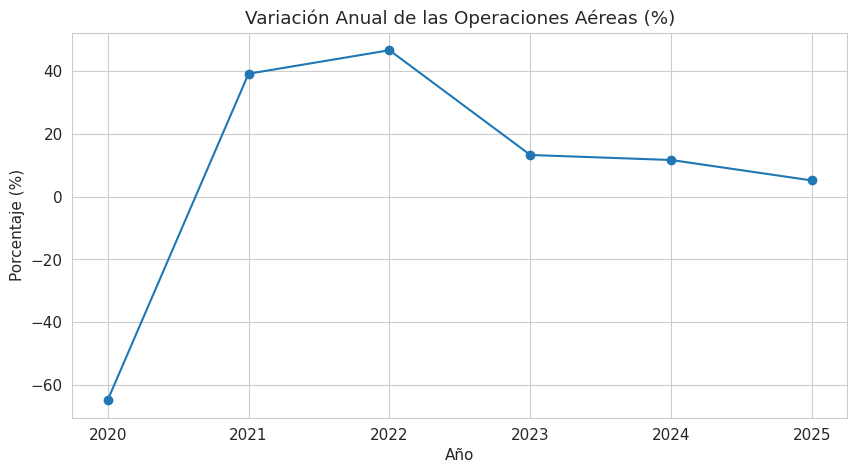

In [30]:
# Visualización de la variación porcentual
# anual de las operaciones aéreas.

plt.figure(figsize=(10,5))

variacion_operaciones.plot(
    marker="o"
)

plt.title(
    "Variación Anual de las Operaciones Aéreas (%)"
)

plt.xlabel("Año")
plt.ylabel("Porcentaje (%)")

plt.grid(True)

plt.show()

**28. Resumen Ejecutivo de KPIs**

In [31]:
# Consolidación de los principales indicadores
# obtenidos durante el análisis.

print("="*50)
print("RESUMEN DE INDICADORES CLAVE")
print("="*50)

print(f"Carga total transportada: {carga_total:,.0f}")
print(f"Total de operaciones: {operaciones_total:,.0f}")

print(f"\nMayor carga: {anio_max_carga}")
print(f"Mayor número de operaciones: {anio_max_operaciones}")

print(f"\nMenor carga: {anio_min_carga}")
print(f"Menor número de operaciones: {anio_min_operaciones}")

RESUMEN DE INDICADORES CLAVE
Carga total transportada: 1,607,446
Total de operaciones: 1,092,250

Mayor carga: 2019
Mayor número de operaciones: 2019

Menor carga: 2020
Menor número de operaciones: 2020


##### *Sección Final: Consultas Analíticas con SQL*

**29. Creación de Base de Datos SQLite**

In [32]:
import sqlite3

conexion = sqlite3.connect("trafico_aereo.db")

df.to_sql(
    "trafico",
    conexion,
    if_exists="replace",
    index=False
)

print("Base de datos creada correctamente.")

Base de datos creada correctamente.


**30. Consulta SQL: Carga Total por Año**

In [33]:

consulta = """
SELECT
    ANIO,
    SUM([TOTAL CARGA NACIONAL] +
        [TOTAL CARGA INTERNACIONA]) AS TOTAL_CARGA
FROM trafico
GROUP BY ANIO
ORDER BY ANIO
"""

pd.read_sql_query(
    consulta,
    conexion
)

,ANIO,TOTAL_CARGA
0,2019,271326.15100
1,2020,190365.06051
2,2021,219202.83707
3,2022,219232.20706
4,2023,211203.39585
5,2024,228963.01900
6,2025,267153.14800


**31. Consulta SQL: Operaciones Totales por Año**

In [34]:
consulta = """
SELECT
    ANIO,
    SUM([TOTAL OPERACION NACIONAL] +
        [TOTAL OPERACION INTERNACIONAL]) AS TOTAL_OPERACIONES
FROM trafico
GROUP BY ANIO
ORDER BY ANIO
"""

pd.read_sql_query(
    consulta,
    conexion
)

,ANIO,TOTAL_OPERACIONES
0,2019,208887
1,2020,73256
2,2021,102005
3,2022,149687
4,2023,169620
5,2024,189492
6,2025,199303


**32. Consulta SQL: Participación Nacional vs Internacional**

In [35]:
consulta = """
SELECT
    SUM([TOTAL CARGA NACIONAL]) AS CARGA_NACIONAL,
    SUM([TOTAL CARGA INTERNACIONA]) AS CARGA_INTERNACIONAL
FROM trafico
"""

pd.read_sql_query(
    consulta,
    conexion
)

conexion.close()